In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
weights = np.load('weights.npz') # NpzFile 'weights.npz' with keys: arr_0, arr_1

In [34]:
arr0 = weights['arr_0']
arr1 = weights['arr_1']

In [35]:
arr0.shape

(5, 5, 1, 32)

In [36]:
_ = [print(arr0[:, :, 0, i]) for i in range(arr0.shape[3])]

[[ 1.  1. -1. -1.  1.]
 [ 1.  1. -1. -1.  1.]
 [ 1. -1. -1. -1.  1.]
 [ 1.  1. -1.  1.  1.]
 [ 1. -1. -1.  1.  1.]]
[[ 1.  1.  1.  1.  1.]
 [-1.  1.  1.  1.  1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [ 1. -1. -1. -1. -1.]]
[[ 1.  1.  1.  1. -1.]
 [-1.  1.  1. -1. -1.]
 [-1. -1.  1. -1. -1.]
 [-1.  1. -1. -1. -1.]
 [ 1.  1. -1. -1. -1.]]
[[-1.  1.  1. -1. -1.]
 [-1.  1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [ 1.  1. -1. -1. -1.]
 [ 1.  1.  1.  1.  1.]]
[[-1.  1.  1.  1. -1.]
 [-1.  1.  1.  1.  1.]
 [-1.  1.  1.  1.  1.]
 [-1.  1.  1. -1. -1.]
 [ 1.  1. -1. -1. -1.]]
[[ 1. -1. -1.  1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [ 1.  1.  1.  1. -1.]
 [ 1.  1.  1.  1.  1.]]
[[-1. -1.  1.  1.  1.]
 [-1. -1. -1.  1.  1.]
 [-1. -1. -1. -1.  1.]
 [ 1.  1. -1. -1.  1.]
 [-1. -1. -1. -1.  1.]]
[[-1. -1. -1. -1. -1.]
 [ 1. -1.  1. -1. -1.]
 [ 1. -1. -1. -1.  1.]
 [ 1. -1. -1.  1.  1.]
 [-1. -1. -1.  1. -1.]]
[[-1.  1. -1.  1. -1.]
 [-1. -1.  1.  1. -1.]
 [ 1. -1. -1.  1.  1.]
 [ 

In [37]:
arr1.shape

(4608, 10)

In [38]:
data = np.load("mnist_augmented4.npz")

In [39]:
images = data["images"].astype("float32") / 255.0   # 0 or 1
images = 2.0 * images - 1.0                     # map {0,1} -> {-1,+1}
labels = data["labels"].astype("int64")

In [40]:
images.shape, labels.shape

((60000, 16, 16), (60000,))

In [41]:
def show_image(images, labels, idx):
    image = images[idx]
    label = labels[idx]
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

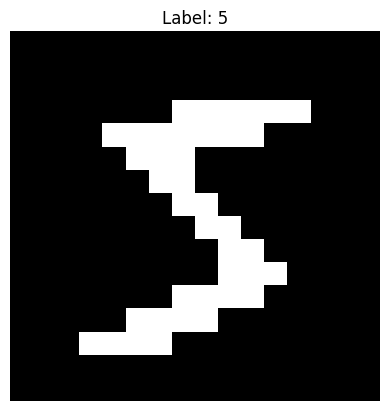

In [42]:
show_image(images, labels, 0)

In [43]:
def softmax(x: np.ndarray) -> np.ndarray:
    """Numerically stable soft‑max."""
    x = x - np.max(x)           # avoid overflow
    e = np.exp(x)
    return e / np.sum(e, keepdims=True)

In [44]:
def classify(img16):
    if img16.ndim == 2:
        img16 = img16[..., None]
    
    scores = np.zeros(10, dtype=np.int32)

    for x_scan in range(12):
        for y_scan in range(12):
            # Extract a 5x5 patch from the image
            patch = img16[y_scan:y_scan+5, x_scan:x_scan+5, :]
            # Convolve the patch with each filter in arr0
            kernels_output = np.zeros(32, dtype=np.int32)
            for k in range(arr0.shape[3]):
                kernel = arr0[..., k]
                # Element-wise multiplication and summation
                kernels_output[k] = np.sign(np.sum(patch * kernel))
            # multiply by corresponding weights in arr1
            for k in range(32):
                for o in range(10):
                    scores[o] += max(0, kernels_output[k] * arr1[k+32*x_scan+32*12*y_scan, o])
    return scores

In [45]:
classify(images[0])

array([2267, 2282, 2344, 2410, 2268, 2463, 2270, 2288, 2296, 2309])

In [46]:
childs = []
for y in range(5):
    for x in range(5):
        for convolution in range(32):
            color = "DF7F01"
            if convolution == 0:
                color = "EEEEEE"
                if x == 0 and y == 0:
                    color = "222222"
                elif x == 0 and y == 1:
                    color = "0A3EE2"
                elif x == 1 and y == 0:
                    color = "D02525"
            childs.append({
                "color": color,
                "controller": {
                    "active": False,
                    "controllers": None,
                    "id": y + 5 * x + 25 * convolution,
                    "joints": None,
                    "mode": 1 if arr0[y, x, 0, convolution] > 0 else 4
                },
                "pos": {
                    "x": x,
                    "y": convolution,
                    "z": -y
                },
                "shapeId": "9f0f56e8-2c31-4d83-996c-d00a9b296c3f",
                "xaxis": 1,
                "zaxis": -2
            })
bodies = [{"childs":childs}]
bp = {"bodies": bodies, "version": 4}
with open("bp.json", "w") as f:
    import json
    json.dump(bp, f, indent=4)

In [47]:
childs = []
for o in range(10):
    for k in range(32):
        color = "DF7F01"
        if o == 0 and k == 0:
            color = "EEEEEE"
        childs.append({
            "color": color,
            "controller": {
                "active": False,
                "controllers": None,
                "id": o + 10 * k,
                "joints": None,
                "mode": 1
            },
            "pos": {
                "x": o,
                "y": k,
                "z": 0
            },
            "shapeId": "9f0f56e8-2c31-4d83-996c-d00a9b296c3f",
            "xaxis": 1,
            "zaxis": -2
        })

for y in range(12):
    for x in range(12):
        color = "DF7F01"
        indices = [x * 32 + y * 32 * 12 + i for i in range(32)]
        weights = arr1[indices, :]
        outputs = []
        for k in range(32):
            for o in range(10):
                if weights[k, o] > 0:
                    outputs.append(k*10+o)
        if len(outputs) > 255:
            split_point = len(outputs) // 2
            outputs1 = outputs[:split_point]
            outputs2 = outputs[split_point:]
            color = "DF7F01"
            for z, out in enumerate([outputs1, outputs2]):
                childs.append({
                    "color": color,
                    "controller": {
                        "active": False,
                        "controllers": [
                            {
                                "id": i,
                            } for i in out
                        ],
                        "id": x * 12 + y + 10000,
                        "joints": None,
                        "mode": 1
                    },
                    "pos": {
                        "x": x+10,
                        "y": 11-y,
                        "z": z
                    },
                    "shapeId": "9f0f56e8-2c31-4d83-996c-d00a9b296c3f",
                    "xaxis": 1,
                    "zaxis": -2
                })
        else:
            color = "DF7F01"
            childs.append({
                "color": color,
                "controller": {
                    "active": False,
                    "controllers": [
                        {
                            "id": i,
                        } for i in outputs
                    ],
                    "id": x * 12 + y + 10000,
                    "joints": None,
                    "mode": 1
                },
                "pos": {
                    "x": x+10,
                    "y": 11-y,
                    "z": 0
                },
                "shapeId": "9f0f56e8-2c31-4d83-996c-d00a9b296c3f",
                "xaxis": 1,
                "zaxis": -2
            })

bodies = [{"childs":childs}]
bp = {"bodies": bodies, "version": 4}
with open("bp.json", "w") as f:
    import json
    json.dump(bp, f, indent=4)

In [ ]:
arr_inp = np.zeros((16, 16), dtype=np.int8)
for i in range(16):
    for j in range(16):
        arr_inp[i, j] = 1 if i % 2 == 0 else -1
[''.join(list(reversed(bin(x)[2:].zfill(12)))) for x in list(classify(arr_inp))]

['111010110001',
 '011000010001',
 '010100010001',
 '011101110001',
 '000001110001',
 '100101010001',
 '001110110001',
 '010101010001',
 '010000001001',
 '110011110001']

In [49]:
# classify a full white image
classify(np.ones((16, 16), dtype=np.float32))

array([2263, 2182, 2186, 2286, 2272, 2217, 2268, 2218, 2306, 2291])